# 7. RANDOM FOREST


El siguiente notebook implementa el preprocesamiento para entrenar un modelo Random Forest de ocurrencia de incendios usando puntos (presencia/ausencia) como unidad de entrenamiento. Se integran bandas espectrales e índices espectrales derivados de imagenes Landsat 8 y Sentinel 1, extrayendolas desde rasters en disco, seleccionados con reglas temporales definidas (L8: mes siguiente; S1: ventana post-incendio).

El notebook:

 -Unifica y reproyecta capas vectoriales a un CRS de trabajo (EPSG:9377).
 -Vincula cada punto con el raster “correspondiente” por reglas temporales.
 -Muestrea valores de bandas en la ubicación del punto (extracción puntual).
 -Construye dos datasets:
   -Dataset A (complete-case): solo filas sin faltantes en features.
   -Dataset B (imputado): rellena faltantes con mediana por clase (presencia vs ausencia).   
 -Ejecuta validación cruzada sin fuga usando grupos por point_id (evita que el mismo punto entre en train y test por duplicación/re-muestreo).
 -Exporta resultados (GeoPackage + CSV + modelos + reporte de CV).

Se cuenta con 90% de entrenamiento y 10% de test para cada uno de los 10 folds que se realiza por Dataset, evitando que un mismo punto este en entrenamiento y test al tiempo y proporción igual de clases. Se cuenta con 500 arboles los cuales disminuyen la varianza 

<font color="red">

En la sección 3 Y 4 del código, es necesario analizar si la asignación de fechas de ausencias basada estrictamente en los registros de incendios, podria inducir en un sesgo estacional. El modelo podría perder la capacidad de reconocer la variabilidad fenológica de las ausencias. Se podrian realizar pruebas segmentadas por temporadas (seca y húmeda) para validar la robustez del modelo ante estos cambios estacionales ¿o de qué manera podríamos garantizar que el modelo aprenda sobre la variabilidad fenologica de las ausencias? A este error se le conoce como efecto espejo

En la parte 6 se poddría ampliar la ventana de busqueda mayor a 1 mes, depende del comportamiento de un punto a traves de los años, por lo menos para retrodispersión: el analisis multitemporal no me permite ver el comportamiento de los puntos como se ve en el notebook 6, 6.2.5  Parte 1 que se ve el comportamiento de 5 puntos en el tiempo.

El modelo actual cuenta con pocos de falsos negativos. Muy bueno prediciendo incendios y malo con no incendios

Se debe indicar el sesgo espacial y describir la relación entre la resolución de MODIS y VIIRS, donde el centroide del pixel representa el punto tomado y este se compara con el pixel de s1 y l8 que estan a mayor resolución que los satelites terra y aqua.

Problemas de autocorrelación espacial por cluster de puntos; la cercania de hasta 5 metros entre puntos de incendios (cada punto con una fecha diferente) podría estar relacionada con la orbita relativa y podría generar problemas de autocorrelación espacial por cluster de puntos?

¿Se debe correr índice de moran para determinar si los puntos son independientes entre si?

¿cual sería la resolución del resultado teniendo en cuenta que se entreno con el centroide de MODIS y resolución espacial de 30 m para las imagenes Landsat 8 y Sentinel 1?

¿se podria ampliar la ventana de busqueda no solo a 1 mes sino a dos meses para mejorar los resultados (imagenes landsat 8 con mascra de nube amplia y sentinel sin cobertura total en ninguno de los meses de analisis) pero no me quda claro como interpretar los resultados de las imagenes Sentinel y su comportamiento multitemporal ver notebook 6
</font>

## 7.1 Parte 1 ##

Se importan librerias, se definen opciones de visualización, se importan métricas y validadores de scikit-lear para el RF; se definen las rutas donde se encuentra las ausencias, incendios, directorios donde estan los rasters a entrenar, excel con los metadatos de las imagenes Sentinel 1 y las salidas a obtener. 

Se definen las relgas temporales tanto para la selecciones de escenas Landsat 8 como Sentinel 1. En el prmer caso se define el mes siguiente y en el segundo se define una venta de imagenes que van desde el dia siguiente del incendio hasta 30 días despues. Se realiza limpieza, manipulación de fechas y manejo de errores; primero se define el formato "dd/mm/aaaa", se determina la selección temporal y matching mensual, se define la mediana inferior para escoger la escena representativa dentro de una ventana S1. Se toma "acq_date" como fecha de incendio para comparar.

Se cargan dos fuentes de datos distintas (puntos donde hubo incendios y donde no), se estandarizan y se unen a un solo conjunto de datos. Se validan las fechas en el formato definido y se reproyectan ambos a EPSG:9377, se concatena y se crea un point_id único. Si hay errores en las fechas el codigo no continua.

Se estandariza y limpia el formato de fechas para el subconjunto de incendios, en caso de encontrar inconsistencias en las fehcas asigna NaT. De acuerdo a lo anterior se le asignan fechas a los puntos de ausencia de incendio, asignandole a cada ausencia una fecha muestreada aleatoriamente desde las fechas reales de incendios con el bojetivo de aplicar las mismas reglas temporales de selección de imanes para ausencias y evitando que el modelo aprenda que presencia = tiene fecha y ausencia =NaT

Se localizan los archivos de imagen dentro del almacenamiento local y se crea un índice organizado para que el modelo identifique qué archivo abrir de acuerdo a la fecha que se necesite consultar. Para las imagenes Landsat 8 se asume que el nombre del archivo contiene la información necesaria. Para el caso de las imagenes Sentinel 1 se emplean los metadatos de la imagen los cuales se encuentran en un excel externo y así saber la fecha de la imagen.

Se realiza la selección temporal tanto para imagenes L8 como para S1, a partir de las ventanas de tiempo definidas para ello (imagenes unicamente para un mes despues del incendio), mediante la función "sample_raster_at_points" donde se extraen los valores de los pixeles para cada una de las imagenes en el punto determinado y se convierten los valores "nodata" en "NaN" para no arruinar los cálculos estadísticos posteriores. 

Se construye un geodataframe donde cada punto corresponde a una fila y las columnas corresponden a las variables tanto de las imagenes Landsat 8 y Sentinel 1. Se realiza normalización de fechas y limpieza de metadatos; se crean las variables finales del modelo y las inicializa en NaN; permite trazabilidad del proceso. Se calcula el mes objetivo por punto y esta información se guarda en columnas, se procesa en grupos (año, mes).

Se concatenan dos listas de nombres de columnas, definiendose las columnas que se usaran en el modelo y se elimina cualquier fila que tenga al menos un valor nulo en cualquiera de las columnas. Se realiza una prueba de validación para confirmar que la función esta funcionando correctamente.

Se evalua si las variables tienen suficientes datos; se evalua cuantos vaores faltantes (NaN) tiene cada feature; se realiza un diagnostico global de clases y ver si el dataset esta desbalanceado antes de conctruir el Dataset A y el Datasdet B; diagnostico de cobertura de Landsat 8 y Sentinel 1.

Se crea la función que construye el Dataset A, donde se conservan los puntos con todas las varibles que existen para ese punto; balanceo exacto 1:1 (incendios y ausencia) preferiblemente en el mismo mes o el mes vecino. allow_replacemente=true permite reemplazar las ausencias, para mantener el balance entre incendios y ausencias para un mismo mes; sin embargo se asignaron las fechas de ausencias semejantes a las de incendio en los puntos aleatorios cercanas al mes de incendio. En caso de que no existan suficientes ausencias el mes siguiente, se reducen las presencias.

Se realiza imputación de NaN por clase a partir de la mediana, donde se eliminan valores faltantes en las variables predictoras, reemplazandose por la mediana, para poder entrenar el Random Forest sin descartar filas (a diferencia del Dataset A. Se contruye el Dataset B donde no se cuenta con ninguna variable con valores NaN y balanceado 1:1 por mes)

Se realiza validación cruzada para garantizar que tan bien generaliza el modelo a datos nuevos, entrenandose 10 veces, evitandose fuga al impedir que el modelo emplee puntos de test como entrenamiento, usando "StratifiedGroupKFold", donde cada reporte produce una evaluación independiente. Se genera reporte en texto de la implementación del modelo en los dos dataset junto con su estadistica descriptiva.

Se genera un reporte en geopackage con la trazabilidad de la información seleccionada para el desarrollo del modelo, se imprime el reporte en texto final y se entregan los modelos tanto del Dataset A como del Dataset B. Se normalizan las fechas; se nornaliza texto en columnas.


In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from pathlib import Path
import logging
import sys

PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src import config_rf_pipeline
from src.pipeline_rf import run_pipeline
from src.config_rf_pipeline import load_config


In [9]:
cfg = load_config(PROJECT / "configs" / "RandomForest_260320.json")

log_path = PROJECT / "logs" / "rf_pipeline_260320.log"
log_path.parent.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(log_path),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger("RandomForest_260320")
logger.info("Inicio pipeline RF")

In [20]:
res = run_pipeline(cfg, logger)

C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\src\points_loader.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  g = pd.concat([g_fire, g_abs], ignore_index=True)


=== DEBUG PRE-CV ===
g_points: (1922, 51)
g_master: (1922, 69)
FEATURES: ['RED', 'NIR', 'SWIR_1', 'SWIR_2', 'NDVI', 'EVI', 'NBR', 'IMG_COUNT', 'VV', 'VH', 'angle']

Conteo label en g_master:
label
1    961
0    961
Name: count, dtype: int64

L8 found:
l8_found
True     1919
False       3
Name: count, dtype: int64

S1 found:
s1_found
False    1372
True      550
Name: count, dtype: int64

NaN por feature en g_master:
RED           780
NIR           780
SWIR_1        780
SWIR_2        780
NDVI          780
EVI           780
NBR           780
IMG_COUNT       3
VV           1683
VH           1683
angle        1610
dtype: int64

Complete cases en FEATURES:
(160, 69)
label
1    141
0     19
Name: count, dtype: int64

dfA shape: (282, 68)
label
1    141
0    141
Name: count, dtype: int64
point_id únicos en dfA: 160

dfB shape: (1922, 68)
label
1    961
0    961
Name: count, dtype: int64
point_id únicos en dfB: 1843


In [22]:
print("OUT_DIR:", res["out_dir"])
print("Features:", res["features"])
print("\nDataset A:", res["dfA"].shape)
print("Dataset B:", res["dfB"].shape)

OUT_DIR: C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260320
Features: ['RED', 'NIR', 'SWIR_1', 'SWIR_2', 'NDVI', 'EVI', 'NBR', 'IMG_COUNT', 'VV', 'VH', 'angle']

Dataset A: (282, 68)
Dataset B: (1922, 68)


In [24]:
display(res["coverage"])

,feature,missing_n,missing_pct
8,VV,1683,87.565036
9,VH,1683,87.565036
10,angle,1610,83.766909
0,RED,780,40.582726
1,NIR,780,40.582726
2,SWIR_1,780,40.582726
3,SWIR_2,780,40.582726
4,NDVI,780,40.582726
5,EVI,780,40.582726
6,NBR,780,40.582726


In [26]:
display(res["foldsA"].head())
display(res["foldsB"].head())

,fold,cv,n_train,n_test,balanced_accuracy,precision_pos,recall_pos,f1_pos,precision_neg,recall_neg,f1_neg,tn,fp,fn,tp
0,1,StratifiedGroupKFold,258,24,0.461538,0.521739,0.923077,0.666667,0.00,0.000000,0.000000,0,11,1,12
1,2,StratifiedGroupKFold,262,20,0.500000,0.650000,1.000000,0.787879,0.00,0.000000,0.000000,0,7,0,13
2,3,StratifiedGroupKFold,266,16,0.628205,0.857143,0.923077,0.888889,0.50,0.333333,0.400000,1,2,1,12
3,4,StratifiedGroupKFold,265,17,0.964286,1.000000,0.928571,0.962963,0.75,1.000000,0.857143,3,0,1,13
4,5,StratifiedGroupKFold,261,21,0.933333,1.000000,0.866667,0.928571,0.75,1.000000,0.857143,6,0,2,13


,fold,cv,n_train,n_test,balanced_accuracy,precision_pos,recall_pos,f1_pos,precision_neg,recall_neg,f1_neg,tn,fp,fn,tp
0,1,StratifiedGroupKFold,1731,191,0.989474,0.979592,1.000000,0.989691,1.000000,0.978947,0.989362,93,2,0,96
1,2,StratifiedGroupKFold,1729,193,0.989583,1.000000,0.979167,0.989474,0.979798,1.000000,0.989796,97,0,2,94
2,3,StratifiedGroupKFold,1733,189,0.994565,0.989796,1.000000,0.994872,1.000000,0.989130,0.994536,91,1,0,97
3,4,StratifiedGroupKFold,1723,199,0.989691,1.000000,0.979381,0.989583,0.980769,1.000000,0.990291,102,0,2,95
4,5,StratifiedGroupKFold,1730,192,0.994792,1.000000,0.989583,0.994764,0.989691,1.000000,0.994819,96,0,1,95


In [28]:
res["g_master"].head()

,idx_firms,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,VV,VH,angle,l8_found,l8_file,l8_year,l8_month,s1_found,s1_file,s1_date
0,7.0,5.78100,-73.56840,322.50,1.20,1.10,2014-09-29,1835,Aqua,MODIS,...,NaN,NaN,NaN,True,L8_2014_10.tif,2014,10,False,None,NaT
1,8.0,5.77960,-73.57840,318.10,1.20,1.10,2014-09-29,1835,Aqua,MODIS,...,NaN,NaN,NaN,True,L8_2014_10.tif,2014,10,False,None,NaT
2,16.0,5.47922,-73.51354,295.42,0.39,0.44,2014-02-04,0645,N,VIIRS,...,NaN,NaN,NaN,True,L8_2014_03.tif,2014,3,False,None,NaT
3,17.0,5.47701,-73.52529,300.45,0.39,0.44,2014-02-04,0645,N,VIIRS,...,NaN,NaN,NaN,True,L8_2014_03.tif,2014,3,False,None,NaT
4,21.0,5.61784,-73.31963,340.57,0.42,0.38,2014-02-02,1826,N,VIIRS,...,NaN,NaN,NaN,True,L8_2014_03.tif,2014,3,False,None,NaT


## 7.2 Aplicación modelo A en imagenes de febrero y marzo de 2016 para detectar incendios de Enero de 2016 ##



Se busca ejecutar la inferencia espacial con Random Forest usando Landsat 8 + Sentinel -1. Objetivos de este notebook:
- cargar `config_ModeloA.json`
- ejecutar el pipeline
- revisar salidas GeoTIFF
- visualizar resultados
- correr validación solo si está activada

Se ejecuta el pipeline, donde:

- carga de modelo
- lectura de L8 y S1
- construcción de features
- inferencia RF
- exportación de `prob.tif` y `bin.tif`
- validación opcional

Ajustar primero el archivo .json con las rutas reales en Windows. Se verifica en donde se encuentra la ruta del archivo. Se alinean ambos raster, ya que se encuentran con extensiones y crs diferentes, tomando como base el GeoTIFF de Landsat 8

In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
from pathlib import Path
import sys

# Root del proyecto: .../tesis_rf
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/Equipo/Tesis/SemestreIV/Objetivo1')

In [48]:
import json
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from src.config_ModeloA import load_config
from src.pipeline_ModeloA import run_pipeline
from src.preprocess_ModeloA import align_raster_to_reference, compare_raster_grids

In [50]:
from src.logging_utils_ModeloA import setup_logger

CONFIG_PATH = PROJECT_ROOT /"Objetivo1_26_02_20"/ "configs" / "config_ModeloA.json"   # ajusta si tu carpeta cambia
cfg = load_config(CONFIG_PATH)
logger = setup_logger(cfg["logging"]["log_file"])

In [52]:
align_before = compare_raster_grids(cfg["paths"]["l8"], cfg["paths"]["s1"])
print(json.dumps(align_before, indent=2, ensure_ascii=False))

{
  "reference_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/L8/L8_2016_02.tif",
  "other_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_V2/S1_2016_2.tif",
  "same_width": false,
  "same_height": false,
  "same_crs": false,
  "same_transform": false,
  "reference_shape": [
    1820,
    2671
  ],
  "other_shape": [
    1816,
    2663
  ],
  "reference_crs": "EPSG:4326",
  "other_crs": "EPSG:32618",
  "reference_transform": [
    0.00026949458523585647,
    0.0,
    -73.68547898977312,
    0.0,
    -0.00026949458523585647,
    5.906243330029031,
    0.0,
    0.0,
    1.0
  ],
  "other_transform": [
    30.0,
    0.0,
    645526.9411940081,
    0.0,
    -30.0,
    653258.6644655439,
    0.0,
    0.0,
    1.0
  ]
}


In [54]:
s1_aligned_path = align_raster_to_reference(
    reference_path=cfg["paths"]["l8"],
    source_path=cfg["paths"]["s1"],
    output_path=cfg["paths"]["s1_aligned"],
    band_map=cfg["s1_band_idx"],
    band_order=["VV", "VH", "angle"],
    resampling_method=cfg["preprocess"]["s1_resampling"],
)

print("S1 alineado creado en:", s1_aligned_path)

S1 alineado creado en: D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\TIFF\S1_V2\S1_2016_2_aligned_to_L8.tif


In [56]:
align_after = compare_raster_grids(cfg["paths"]["l8"], cfg["paths"]["s1_aligned"])
print(json.dumps(align_after, indent=2, ensure_ascii=False))

{
  "reference_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/L8/L8_2016_02.tif",
  "other_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_V2/S1_2016_2_aligned_to_L8.tif",
  "same_width": true,
  "same_height": true,
  "same_crs": true,
  "same_transform": true,
  "reference_shape": [
    1820,
    2671
  ],
  "other_shape": [
    1820,
    2671
  ],
  "reference_crs": "EPSG:4326",
  "other_crs": "EPSG:4326",
  "reference_transform": [
    0.00026949458523585647,
    0.0,
    -73.68547898977312,
    0.0,
    -0.00026949458523585647,
    5.906243330029031,
    0.0,
    0.0,
    1.0
  ],
  "other_transform": [
    0.00026949458523585647,
    0.0,
    -73.68547898977312,
    0.0,
    -0.00026949458523585647,
    5.906243330029031,
    0.0,
    0.0,
    1.0
  ]
}


In [58]:
cfg["paths"]["s1"] = cfg["paths"]["s1_aligned"]
results = run_pipeline(cfg, logger)
results

2026-03-26 12:50:00 | INFO | logs/pipeline_260326.log | Iniciando pipeline de inferencia RF
2026-03-26 12:50:00 | INFO | logs/pipeline_260326.log | Modelo: C:/Users/Equipo/Tesis/SemestreIV/Objetivo1/Objetivo1_26_02_20/outputs/outputs_rf_pipeline_260320/modelo_RF_A_60320.pkl
2026-03-26 12:50:00 | INFO | logs/pipeline_260326.log | L8: D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/L8/L8_2016_02.tif
2026-03-26 12:50:00 | INFO | logs/pipeline_260326.log | S1: D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_V2/S1_2016_2_aligned_to_L8.tif
2026-03-26 12:50:00 | INFO | logs/pipeline_260326.log | Alineación raster: {'same_width': True, 'same_height': True, 'same_crs': True, 'same_transform': True, 'l8_shape': (1820, 2671), 's1_shape': (1820, 2671), 'l8_crs': 'EPSG:4326', 's1_crs': 'EPSG:4326'}
2026-03-26 12:50:05 | INFO | logs/pipeline_260326.log | Resumen inferencia: {'pixels_totales': 4861220, 'pixels_validos': 1180728, 'pct_validos': 24.288717647010422, 'n_features': 

{'mode': 'in_memory',
 'summary': {'pixels_totales': 4861220,
  'pixels_validos': 1180728,
  'pct_validos': 24.288717647010422,
  'n_features': 11,
  'features': ['RED',
   'NIR',
   'SWIR_1',
   'SWIR_2',
   'NDVI',
   'EVI',
   'NBR',
   'IMG_COUNT',
   'VV',
   'VH',
   'angle']},
 'outputs': {'prob': 'outputs/rasters/rf_probabilidad_quemado_260326.tif',
  'bin': 'outputs/rasters/rf_quemado_binario_260326.tif'},
 'validation': {'n_puntos_incendio': 33,
  'n_muestras_validas': 26,
  'tp_rate_sobre_presencia': 84.61538461538461,
  'prob_media_en_incendios': 0.8538461923599243}}

Así se ven los resultados, porque las imagenes cuentan con esta cobertura reducida, tanto para Landsat 8 como para Sentinel 1:

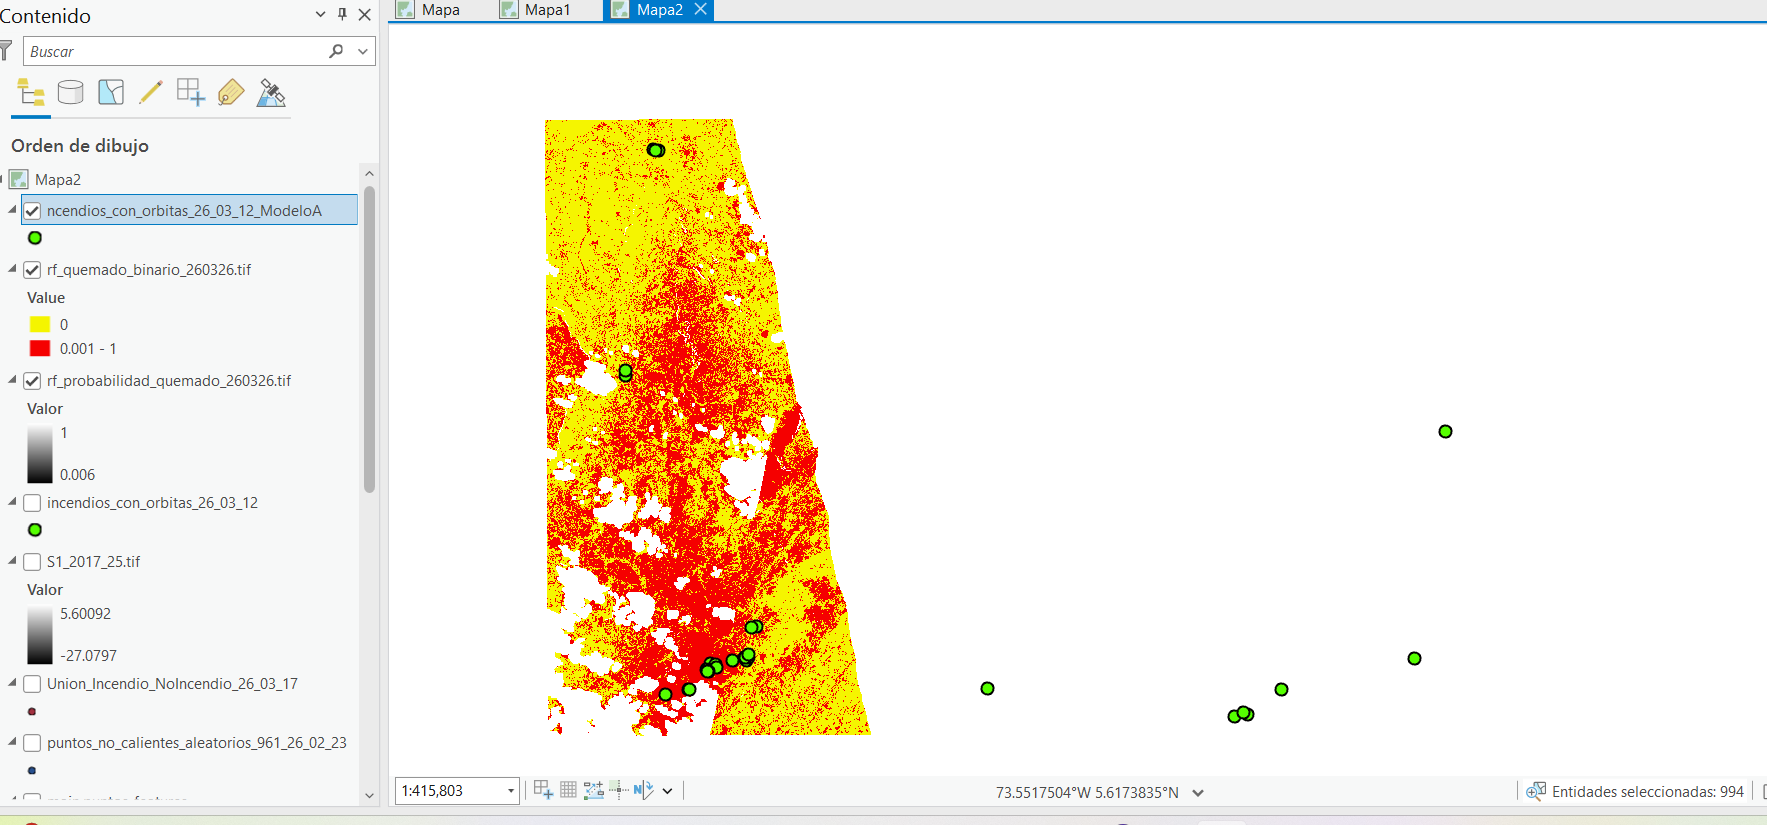